# Support Vector Machine (SVM) From Scratch

Implementation of a Linear Support Vector Machine (Soft Margin) from scratch using **NumPy** , **Matplotlib** and **Stochastic Gradient Descent (SGD)**.

This notebook covers the mathematical intuition behind SVM, implements the optimization algorithm from scratch, and compares the results with Scikit-learn's implementation.

# Theory

Support Vector Machine (SVM) is a supervised learning algorithm used for classification tasks.

The objective of SVM is to find the optimal hyperplane that maximizes the margin between different classes while minimizing classification errors.

This implementation uses:

- Soft Margin SVM
- Hinge Loss
- L2 Regularization
- Stochastic Gradient Descent (SGD)

Kernel methods are discussed separately and are not implemented in this notebook.
## Objective Function

The optimization problem is defined as:

$$
\lambda\frac{1}{2}\|w\|^2+\sum_{i=1}^{n}\max(0,1-y_i(w^Tx_i+b))
$$

where:

- **w** : Weight vector
- **b** : Bias
- **λ** : Regularization parameter
- **yᵢ** : Class label (-1 or +1)
- **xᵢ** : Training sample

The first term minimizes the weight magnitude (maximizing the margin), while the second term is the Hinge Loss that penalizes samples inside the margin or incorrectly classified samples.
## Margin

For each training sample, the margin is computed as

$$
\text{margin}=y_i(w^Tx_i+b)
$$

If

$$
\text{margin}\ge1
$$

the sample is correctly classified and lies outside the margin.

Otherwise, the sample is either inside the margin or misclassified.
## Hinge Loss

The Hinge Loss is defined as

$$
L=\max(0,1-y_i(w^Tx_i+b))
$$

The loss is:

- **0** when the sample satisfies the margin.
- **Positive** when the sample is inside the margin or misclassified.
## Gradient Update

If

$$
y_i(w^Tx_i+b)\ge1
$$

$$
\nabla_w=\lambda w
$$

Otherwise

$$
\nabla_w=\lambda w-y_i x_i
$$

$$
\nabla_b=- y_i
$$

The parameters are updated using Stochastic Gradient Descent (SGD).

# Implementation

In this section, we implement a Linear Soft Margin SVM from scratch using NumPy.

The implementation includes:

- Weight initialization
- Margin computation
- Hinge Loss
- L2 Regularization
- SGD optimization
- Prediction
- Accuracy evaluation

In [21]:
import numpy as np
import matplotlib.pyplot as plt
class SVM:
    def __init__(self,max_iter=100 , learning_rate=0.1 ,lambda_param = 0.1):
        self.lambda_ = lambda_param
        self.learning_rate=learning_rate
        self.max_iter = max_iter
        self.w=None
        self.b=0
        self.loss_history=[]
    def fit(self,X,y):
        y= np.where(y<=0 , -1 ,1)
        n_features=X.shape[1]
        self.w=np.zeros(n_features)
        self.b = 0
        for _ in range(self.max_iter):
            epoch_loss = 0
            for idx ,x_i in enumerate(X):
                margin = y[idx] * (np.dot(x_i , self.w) + self.b)
                epoch_loss += self.loss_function(margin)
                
                if margin >= 1 :
                    self._update_margin_satisfied()
                else :
                    self._update_margin_violated(x_i , y[idx])
                
            self.loss_history.append(epoch_loss)
    def _update_margin_violated(self, x, y):

        dw = self.lambda_ * self.w - y*x
        db = -y

        self.w -= self.learning_rate * dw
        self.b -= self.learning_rate * db


    def _update_margin_satisfied(self):

        dw = self.lambda_ * self.w

        self.w -= self.learning_rate * dw
    def loss_function(self, margin):

        hinge = np.maximum(0, 1-margin)

        return (
        0.5 * self.lambda_ * np.sum(self.w**2)
        + hinge
        )
    def _predict_one(self , x):
        value=np.sign(np.dot(self.w,x)+self.b).item()
        if value == 0:
            return 1
        return value
    def predict(self , x_test  ):
        return np.array([self._predict_one(i) for i in x_test])
    def score(self, X, y):
        pred = self.predict(X)
        y = np.where(y <= 0, -1, 1)
        return np.mean(np.array(pred) == y)
    def decision_function(self, X):
        return np.dot(X, self.w) + self.b


    def plot_decision_boundary(self , X, y):

    
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    
        xx, yy = np.meshgrid(
            np.arange(x_min, x_max, 0.02),
            np.arange(y_min, y_max, 0.02)
        )

    
        grid = np.c_[xx.ravel(), yy.ravel()]

   
        Z = np.array(self.predict(grid))

        Z = Z.reshape(xx.shape)

    
        plt.figure(figsize=(8,6))

        plt.contourf(xx, yy, Z, alpha=0.3)

    
        plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        edgecolors="k",
        s=60
        )

        plt.title("SVM Decision Boundary")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")

        plt.show()


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# Load dataset
iris = load_iris()

X = iris.data
y = iris.target


# Binary classification (remove class 2)
mask = y != 2

X = X[mask]
y = y[mask]


# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM from Scratch 

model = SVM(
    max_iter=5000,
    learning_rate=0.01,
    lambda_param=0.01
)

model.fit(X_train, y_train)

my_pred = model.predict(X_test)

my_accuracy = model.score(
    X_test , y_test
)


print("From Scratch SVM Accuracy:", my_accuracy)


# =========================
# Sklearn SVM
# =========================

svc = SVC(kernel="linear")

svc.fit(X_train, y_train)

sk_pred = svc.predict(X_test)

sk_accuracy = np.mean(sk_pred == y_test)


print("Sklearn SVM Accuracy:", sk_accuracy)



From Scratch SVM Accuracy: 1.0
Sklearn SVM Accuracy: 1.0


# Training Loss

The following plot illustrates how the objective function decreases during training.

A decreasing loss generally indicates that the optimization process is converging.

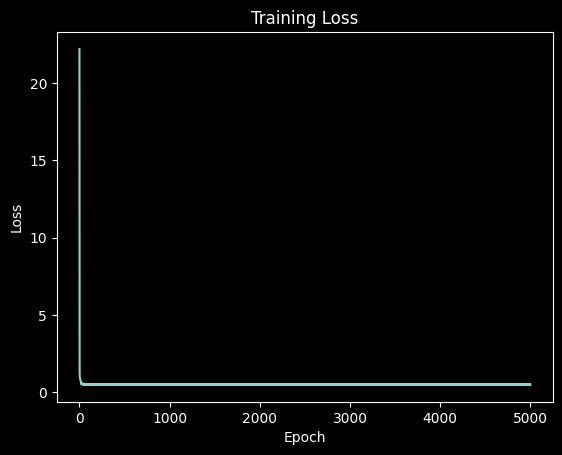

In [23]:
plt.plot(model.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

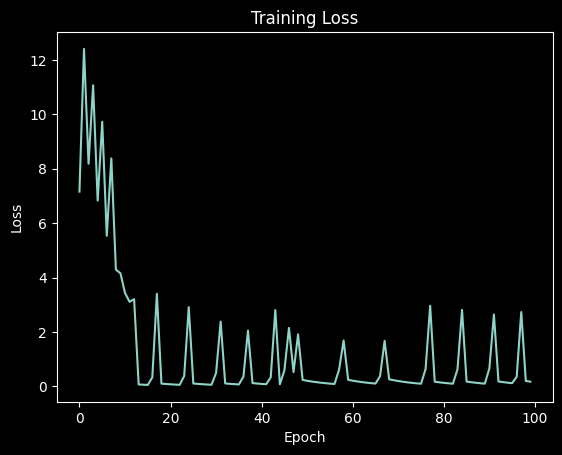

[3.27483523 3.10887515 2.1686569 ]


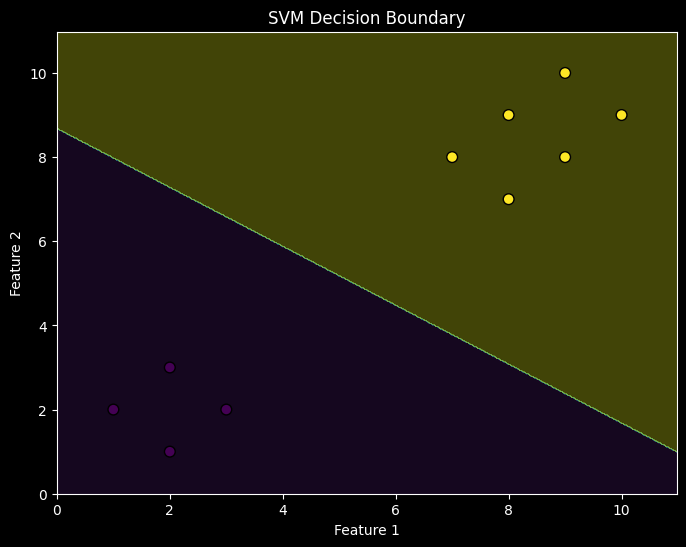

None


(array([1., 1., 1.]), array([1, 1, 1]))

In [24]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1,2],
    [2,1],
    [2,3],
    [3,2],
    [8,9],
    [9,8],
    [8,7],
    [7,8],
    [10,9],
    [9,10]
])

y = np.array([
    -1,-1,-1,-1,
    1,1,1,1,1,1
])
np.random.seed(42)

mask = np.random.rand(len(X)) > 0.2 


x_train = X[mask]
y_train = y[mask]

x_test = X[~mask]
y_test = y[~mask]
model = SVM()
model.fit(x_train , y_train)
pred = model.predict(x_test)

plt.plot(model.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()
print(model.decision_function(x_test))
print(model.plot_decision_boundary(X , y))
pred , y_test

# Decision Boundary

The following visualization illustrates how the trained SVM separates the two classes in the feature space.

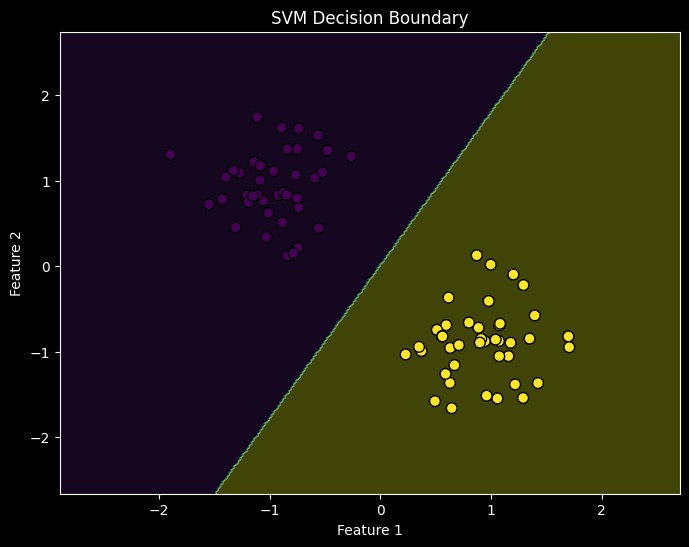

In [25]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_blobs(
    n_samples=100,
    centers=2,
    random_state=42,
    cluster_std=1.5
)

y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = SVM(
    max_iter=5000,
    learning_rate=0.01,
    lambda_param=0.01
)

model.fit(X_train, y_train)

model.plot_decision_boundary( X_train, y_train)

# Conclusion

In this notebook, we implemented a Linear Soft Margin Support Vector Machine (SVM) from scratch using NumPy.

The implementation includes:

- Soft Margin optimization
- Hinge Loss
- L2 Regularization
- SGD-based training
- Prediction
- Model evaluation

Finally, the implementation was compared with Scikit-learn's SVM to validate its performance.